In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('Cafe_sales.csv')

In [2]:
log = [] 
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


- UNKNOWN, ERROR, and NaN values in columns

In [3]:
org_dtypes = df.dtypes

#### All type object
- Convert:
    - Quantity -> INT64
    - Price Per Unit -> FLOAT
    - Total Spent -> FLOAT
    - Transaction Date -> DateTime
- Convert types to run get a proper description

In [4]:
org_shape = df.shape

In [5]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [6]:
df['Quantity'].nunique()
df['Quantity'].value_counts()

Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
Name: count, dtype: int64

- Only has UNKNOWN & ERROR values all others are valid ints
- Fill as NaNs for now to convert dtype 
    - Will lookup to match and fill with (Total Spent/Price Per Unit)

In [7]:
invalid_values = ['UNKNOWN', 'ERROR']
df['Quantity'].isin(invalid_values)
df['Quantity'] = df['Quantity'].replace(invalid_values, np.nan)

In [8]:
assert not (df['Quantity'].isin(invalid_values)).any()

In [9]:
df['Quantity'] = df['Quantity'].astype('Int64')

In [10]:
df['Price Per Unit'].nunique()
df['Price Per Unit'].value_counts()

Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
UNKNOWN     164
Name: count, dtype: int64

- Same as Quantity
    - lookup later, where Item with Price Per Unit matches: take that value

In [11]:
df['Price Per Unit'].isin(invalid_values)
df['Price Per Unit'] = df['Price Per Unit'].replace(invalid_values, np.nan)

In [12]:
assert not (df['Price Per Unit'].isin(invalid_values)).any()

In [13]:
df['Price Per Unit'] = df['Price Per Unit'].astype(float)

In [14]:
df['Total Spent'].nunique()
df['Total Spent'].value_counts()

Total Spent
6.0        979
12.0       939
3.0        930
4.0        923
20.0       746
15.0       734
8.0        677
10.0       524
2.0        497
9.0        479
5.0        468
16.0       444
25.0       259
7.5        237
1.0        232
4.5        225
1.5        205
UNKNOWN    165
ERROR      164
Name: count, dtype: int64

- Same as Quantity
    - Lookup later, Total Spent = Price Per Unit * Quantity

In [15]:
df['Total Spent'].isin(invalid_values)
df['Total Spent'] = df['Total Spent'].replace(invalid_values,np.nan)

In [16]:
assert not (df['Total Spent'].isin(invalid_values)).any()

In [17]:
df['Total Spent'] = df['Total Spent'].astype(float)

In [18]:
log.append("Changed data type of Quantity to Int64 and Price Per Unit, Total Spent float64")

In [19]:
df.dtypes

Transaction ID       object
Item                 object
Quantity              Int64
Price Per Unit      float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
dtype: object

In [20]:
org_desc = df.describe(include='all')
org_nulls = df.isna().sum()

In [21]:
org_desc

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9521.0,9467.000000,9498.000000,7421,6735,9841
unique,10000,10,<NA>,NaN,NaN,5,4,367
top,TXN_1961373,Juice,<NA>,NaN,NaN,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,<NA>,NaN,NaN,2291,3022,159
mean,NaN,NaN,3.028463,2.949984,8.924352,NaN,NaN,NaN
std,NaN,NaN,1.419007,1.278450,6.009919,NaN,NaN,NaN
min,NaN,NaN,1.0,1.000000,1.000000,NaN,NaN,NaN
25%,NaN,NaN,2.0,2.000000,4.000000,NaN,NaN,NaN
50%,NaN,NaN,3.0,3.000000,8.000000,NaN,NaN,NaN
75%,NaN,NaN,4.0,4.000000,12.000000,NaN,NaN,NaN


##### First Glance goals:
- Deal with Nulls created above, and the rest of Nulls in columns
- Deal with the UNKNOWN, ERROR in columns
- Resolve datatype of Transaction date

In [22]:
df['Transaction Date'].unique()
df[df['Transaction Date'].isin(invalid_values) | df['Transaction Date'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
11,TXN_3051279,Sandwich,2,4.0,8.0,Credit Card,Takeaway,ERROR
29,TXN_7640952,Cake,4,3.0,12.0,Digital Wallet,Takeaway,ERROR
33,TXN_7710508,UNKNOWN,5,1.0,5.0,Cash,NaN,ERROR
77,TXN_2091733,Salad,1,5.0,5.0,NaN,In-store,NaN
103,TXN_7028009,Cake,4,3.0,12.0,NaN,Takeaway,ERROR
...,...,...,...,...,...,...,...,...
9933,TXN_9460419,Cake,1,3.0,3.0,NaN,Takeaway,UNKNOWN
9937,TXN_8253472,Cake,1,3.0,3.0,NaN,NaN,UNKNOWN
9949,TXN_3130865,Juice,3,3.0,9.0,NaN,In-store,UNKNOWN
9983,TXN_9226047,Smoothie,3,4.0,12.0,Cash,NaN,UNKNOWN


- 460 rows missing Transaction date

In [23]:
df['Location'].unique()
df[df['Location'] == 'Takeaway']
df[df['Location'] == 'In-store']
df['Payment Method'].unique()

array(['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR', nan],
      dtype=object)

- There doesn't seem to be any relationship in the missing Transaction Dates so these are entry errors.
- Mark as pd.na, and convert column to datetime

In [24]:
df['Transaction Date'] = df['Transaction Date'].replace(invalid_values,np.nan)

In [25]:
filt = df['Transaction Date'].notnull()
notnull_dates = df['Transaction Date'].loc[filt]
pd.to_datetime(notnull_dates,format='%Y-%m-%d')

0      2023-09-08
1      2023-05-16
2      2023-07-19
3      2023-04-27
4      2023-06-11
          ...    
9995   2023-08-30
9996   2023-06-02
9997   2023-03-02
9998   2023-12-02
9999   2023-11-07
Name: Transaction Date, Length: 9540, dtype: datetime64[ns]

- Datetime(string) format is consistent throughout (YYYY-MM-DD)

In [26]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], format='%Y-%m-%d', errors='coerce')

In [27]:
assert (df['Transaction Date'].between('2023-01-01','2023-12-31') | df['Transaction Date'].isna()).all()
log.append("Changed Transaction Date datatype to datetime")

In [28]:
df.dtypes

Transaction ID              object
Item                        object
Quantity                     Int64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

All the data type issues have been dealt with

In [29]:
# Duplicates
df.duplicated().sum()
df.duplicated(subset=['Transaction ID']).sum() 

np.int64(0)

In [30]:
df.loc[df.duplicated(subset=['Item', 'Price Per Unit','Quantity','Total Spent','Location','Payment Method','Transaction Date'])]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
675,TXN_2601689,Salad,4,5.0,20.0,Digital Wallet,Takeaway,2023-01-14
1136,TXN_3412490,Cake,2,3.0,6.0,Cash,In-store,NaT
1367,TXN_5566652,Juice,5,3.0,15.0,Credit Card,NaN,2023-09-16
1414,TXN_2952715,Smoothie,3,4.0,12.0,Cash,In-store,NaT
1521,TXN_6817795,Tea,1,1.5,1.5,Cash,Takeaway,2023-09-12
...,...,...,...,...,...,...,...,...
9909,TXN_2112522,Sandwich,5,4.0,20.0,Digital Wallet,Takeaway,2023-04-30
9930,TXN_4428252,Sandwich,3,4.0,12.0,NaN,Takeaway,2023-10-31
9967,TXN_8563793,Juice,4,3.0,12.0,NaN,In-store,2023-03-26
9983,TXN_9226047,Smoothie,3,4.0,12.0,Cash,NaN,NaT


- Data insufficient to mark these as duplicates As there are:
    - No duplicate transaction IDs
    - No Time feature
    - No Customer information
- There can be same type of orders placed on the same day
- It is safe to say, there are no duplicate transactions

In [31]:
# String Columns 1) Strip
df['Transaction ID'] = df['Transaction ID'].str.strip()
df['Item'] = df['Item'].str.strip()
df['Location'] = df['Location'].str.strip()
df['Payment Method'] = df['Payment Method'].str.strip()

In [ ]:
# 2) Normalize required columns
df[['Transaction ID', 'Item', 'Location', 'Payment Method']]
# All the columns are already titled except for ID keep it as is, run .title 
df['Item'] = df['Item'].str.title()
df['Location'] = df['Location'].str.title() 
df['Payment Method'] = df['Payment Method'].str.title()

In [33]:
log.append("Stripped and titled str columns")

In [34]:
df['Item'].value_counts()
df['Location'].value_counts() 
df['Payment Method'].value_counts()

Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
Error              306
Unknown            293
Name: count, dtype: int64

In [35]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     460
dtype: int64

In [36]:
df[~df['Transaction ID'].str.contains('TXN')]
df[~df['Transaction ID'].str.startswith('TXN')]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


- Transaction ID appears to be clean (no nulls, no unexpected IDs)
- Deal with the missing values in all the columns 
    - earlier columns where datatype changed got all missing values as NULLs
    - The object ones have Unkown, Error, Nulls ()

In [37]:
# Clean Price Per Unit
grp = df.groupby(['Item'])
grp['Price Per Unit'].unique()

Item
Cake                                 [3.0, nan]
Coffee                               [2.0, nan]
Cookie                               [1.0, nan]
Error       [1.5, 3.0, 5.0, nan, 4.0, 2.0, 1.0]
Juice                                [3.0, nan]
Salad                                [5.0, nan]
Sandwich                             [4.0, nan]
Smoothie                             [4.0, nan]
Tea                                  [1.5, nan]
Unknown     [3.0, 1.0, 5.0, 4.0, 1.5, 2.0, nan]
Name: Price Per Unit, dtype: object

- No different Price Per Unit for any product ( NULLs in Price Per Unit)
- These products have same Price Per Unit
    - 3.0 -> Cake, Juice
    - 4.0 -> Sandwich, Smoothie

In [38]:
lookup = df[(df['Price Per Unit'].notnull()) & ~(df['Item'].isin(['Error','Unknown']))].groupby('Item')['Price Per Unit'].first()
mask = df['Price Per Unit'].isna()
df.loc[mask, 'Price Per Unit'] = df.loc[mask , ('Item')].map(lookup)

- Price Per Unit for all the Items is the exact same so first() is safe to use

In [39]:
log.append("Looked up Price Per Unit values (where NaN) compare with Item to fill")

In [40]:
assert (df.loc[df['Price Per Unit'].isna() & (df['Item'].isin(['Error', 'Unknown']) | df['Item'].isna()),'Transaction ID'].count() == (df['Price Per Unit'].isna().sum()))

- All the missing Price Per Unit are those where Item is Unknown, Error, or NaN

In [41]:
# clean Item
PRICE_TO_ITEM = {1:'Cookie', 1.5:'Tea', 2:'Coffee', 5:'Salad'}
def fill_items_from_price(df, price_to_item):
    for price,item in PRICE_TO_ITEM.items():
        mask = ( np.isclose(df['Price Per Unit'], price) &
            (df['Item'].isin(['Unknown','Error']) | df['Item'].isna())
            )
        df.loc[mask,'Item'] = item
    return df
df = fill_items_from_price(df,PRICE_TO_ITEM)

- Set the Error and Unknown -where the same Price has two units- to the most selling one amongst the two

In [42]:
df.groupby(df['Item'])['Quantity'].sum()

Item
Cake        3329
Coffee      3679
Cookie      3425
Error        467
Juice       3373
Salad       3644
Sandwich    3245
Smoothie    3221
Tea         3441
Unknown      453
Name: Quantity, dtype: Int64

- Sandwich has more sales for Price Per Unit 4
- Juice has more sales for Price Per Unit 3

In [43]:
PRICE_TO_ITEM.update({3:'Juice', 4:'Sandwich'}) 
df = fill_items_from_price(df,PRICE_TO_ITEM)

In [44]:
log.append("Set the missing Item to Item with the same Price Per Unit, and where multiple Items had same price filled the missing item with most selling")

In [45]:
df[df['Item'].isin(['Unknown', 'Error'])]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
118,TXN_4633784,Error,5,NaN,15.0,NaN,In-Store,2023-02-06
550,TXN_4186681,Error,4,NaN,6.0,Digital Wallet,NaN,2023-05-24
750,TXN_5787508,Error,3,NaN,9.0,Credit Card,Takeaway,2023-07-23
1154,TXN_2473090,Unknown,2,NaN,3.0,Credit Card,In-Store,2023-03-03
1337,TXN_5031214,Error,5,NaN,5.0,NaN,Takeaway,2023-07-29
1377,TXN_8396271,Error,2,NaN,2.0,NaN,NaN,2023-09-12
1786,TXN_1923349,Error,4,NaN,6.0,NaN,NaN,2023-07-06
2227,TXN_3200203,Error,2,NaN,8.0,NaN,Unknown,2023-12-04
2289,TXN_7524977,Unknown,4,NaN,NaN,Error,NaN,2023-12-09
2962,TXN_9702662,Unknown,4,NaN,16.0,NaN,Takeaway,2023-07-10


- Remaining missing Items are those where Price Per Unit is missing too
    - Lookup Price First then comeback to these

In [46]:
df[df['Quantity'].isna() & df['Price Per Unit'].isna() & df['Total Spent'].isna()]
cond1 = (df['Quantity'].isna() & df['Price Per Unit'].isna())
cond2 = (df['Quantity'].isna() & df['Total Spent'].isna())
cond3 = (df['Price Per Unit'].isna() & df['Total Spent'].isna())

- None of the rows are missing all three numeric columns
- There are rows missing multiple values so these cannot be used for calculating numeric columns or Item
    - Mark these with a flag
    - Total value or Quantity can be used for analysis so not dropping the rows

In [47]:
df['IsUnusable'] = (cond1 | cond2 | cond3)

In [48]:
log.append("Created IsUnusable flag column to highlight columns missing 2 numeric columns -instead of dropping")

In [49]:
mask = df['Price Per Unit'].isna() & ~df['IsUnusable']
df.loc[mask, 'Price Per Unit'] = df.loc[mask, 'Total Spent'] / df.loc[mask, 'Quantity']

In [50]:
assert not (~df['IsUnusable'] & df['Price Per Unit'].isna()).any()

In [51]:
log.append("Set the missing Price Per Unit to Total Spent / Quantity")

In [52]:
df[(~df['IsUnusable']) & (df['Item'].isin(['Unknown','Error']) | df['Item'].isna())]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,IsUnusable
118,TXN_4633784,Error,5,3.0,15.0,NaN,In-Store,2023-02-06,False
151,TXN_4031509,NaN,4,4.0,16.0,Credit Card,Takeaway,2023-01-04,False
289,TXN_3495950,NaN,4,1.5,6.0,Credit Card,In-Store,2023-02-19,False
334,TXN_2523298,NaN,4,1.5,6.0,Error,In-Store,2023-03-25,False
550,TXN_4186681,Error,4,1.5,6.0,Digital Wallet,NaN,2023-05-24,False
750,TXN_5787508,Error,3,3.0,9.0,Credit Card,Takeaway,2023-07-23,False
818,TXN_7940202,NaN,1,4.0,4.0,Digital Wallet,NaN,2023-07-23,False
1154,TXN_2473090,Unknown,2,1.5,3.0,Credit Card,In-Store,2023-03-03,False
1337,TXN_5031214,Error,5,1.0,5.0,NaN,Takeaway,2023-07-29,False
1377,TXN_8396271,Error,2,1.0,2.0,NaN,NaN,2023-09-12,False


In [53]:
df = fill_items_from_price(df,PRICE_TO_ITEM)

In [54]:
assert not ((~df['IsUnusable']) & (df['Item'].isin(['Unknown','Error']) | df['Item'].isna())).any()

In [55]:
log.append("After assigning Price Per Unit missing values popped up in Item again, dealt the same way as earlier")

In [56]:
df[(df['IsUnusable']==False) & (df['Item'].isin(['Unknown','Error']) | df['Item'].isna())]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,IsUnusable


In [57]:
df[df['Price Per Unit'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,IsUnusable
1761,TXN_3611851,NaN,4,NaN,NaN,Credit Card,NaN,2023-02-09,True
2289,TXN_7524977,Unknown,4,NaN,NaN,Error,NaN,2023-12-09,True
3779,TXN_7376255,Unknown,<NA>,NaN,25.0,NaN,In-Store,2023-05-27,True
4152,TXN_9646000,Error,2,NaN,NaN,NaN,In-Store,2023-12-14,True
7597,TXN_1082717,Error,<NA>,NaN,9.0,Digital Wallet,In-Store,2023-12-13,True
9819,TXN_1208561,NaN,<NA>,NaN,20.0,Credit Card,NaN,2023-08-19,True


In [58]:
new_grp = df.groupby(df.loc[~df['IsUnusable'],'Item'])
new_grp['Price Per Unit'].unique()

Item
Cake        [3.0]
Coffee      [2.0]
Cookie      [1.0]
Juice       [3.0]
Salad       [5.0]
Sandwich    [4.0]
Smoothie    [4.0]
Tea         [1.5]
Name: Price Per Unit, dtype: object

- Items and Price Per Unit dealt with

In [59]:
df[df['IsUnusable']==False].isna().sum()

Transaction ID         0
Item                   0
Quantity             456
Price Per Unit         0
Total Spent          479
Payment Method      2570
Location            3257
Transaction Date     460
IsUnusable             0
dtype: int64

In [60]:
# Clean Quantity
df[df['Quantity'].isna()]
mask = df['Quantity'].isna() & ~df['IsUnusable']
df.loc[mask, 'Quantity'] = (df.loc[mask,'Total Spent'] / df.loc[mask,'Price Per Unit']).round().astype('Int64')

In [61]:
log.append("Set Quantity = Total Spent / Price Per Unit where missing")

In [62]:
df[df['Total Spent'].isna()]
mask = df['Total Spent'].isna() & ~df['IsUnusable']
df.loc[mask, 'Total Spent'] = df.loc[mask,'Quantity'] * df.loc[mask,'Price Per Unit'] 

In [63]:
log.append("Set Total Spent = Quantity * Price Per Unit where missing")

In [64]:
df[~df['IsUnusable']].isna().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2570
Location            3257
Transaction Date     460
IsUnusable             0
dtype: int64

In [65]:
df['Payment Method'].unique()
mask = (df['Payment Method'].isin(['Unknown','Error']) | df['Payment Method'].isna()) & (~df['IsUnusable'])
df.loc[mask]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,IsUnusable
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,2023-04-27,False
6,TXN_4433211,Juice,3,3.0,9.0,Error,Takeaway,2023-10-06,False
8,TXN_4717867,Juice,5,3.0,15.0,NaN,Takeaway,2023-07-28,False
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-Store,2023-12-31,False
13,TXN_9437049,Cookie,5,1.0,5.0,NaN,Takeaway,2023-06-01,False
...,...,...,...,...,...,...,...,...,...
9985,TXN_3297457,Cake,2,3.0,6.0,NaN,Unknown,2023-01-03,False
9988,TXN_9594133,Cake,5,3.0,15.0,Error,NaN,NaT,False
9992,TXN_2739140,Smoothie,4,4.0,16.0,Unknown,In-Store,2023-07-05,False
9994,TXN_7851634,Sandwich,4,4.0,16.0,NaN,NaN,2023-01-08,False


In [66]:
items_grp = df[mask].groupby('Item')['Payment Method']
items_grp.value_counts(dropna=False)

Item      Payment Method
Cake      NaN               284
          Error              41
          Unknown            39
Coffee    NaN               382
          Error              38
          Unknown            33
Cookie    NaN               297
          Error              37
          Unknown            35
Juice     NaN               332
          Unknown            47
          Error              44
Salad     NaN               304
          Error              42
          Unknown            28
Sandwich  NaN               359
          Unknown            41
          Error              29
Smoothie  NaN               280
          Error              39
          Unknown            34
Tea       NaN               332
          Unknown            36
          Error              35
Name: count, dtype: int64

- No particular items have more missing Payment Method values than others

In [67]:
month_grp = df[mask].groupby(df['Transaction Date'].dt.month_name())
month_grp['Payment Method'].size()

Transaction Date
April        260
August       235
December     244
February     239
January      262
July         247
June         263
March        257
May          266
November     231
October      267
September    234
Name: Payment Method, dtype: int64

- No values lost
    - otherwise missing values would be concentrated on a single month

- No pattern visible in the missing values of Payment Method
    - Even where Error the transaction seems legit and processed
    - Replace all with Unavailable

In [68]:
df.loc[mask,'Payment Method'] = 'Unavailable'

In [69]:
df['Location'].unique()
mask = (df['Location'].isin(['Unknown','Error']) | df['Location'].isna()) & (~df['IsUnusable'])
df.loc[mask]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,IsUnusable
3,TXN_7034554,Salad,2,5.0,10.0,Unavailable,Unknown,2023-04-27,False
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31,False
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,Unknown,2023-10-28,False
16,TXN_3765707,Sandwich,1,4.0,4.0,Unavailable,NaN,2023-06-10,False
18,TXN_8876618,Cake,5,3.0,15.0,Cash,Error,2023-03-25,False
...,...,...,...,...,...,...,...,...,...
9994,TXN_7851634,Sandwich,4,4.0,16.0,Unavailable,NaN,2023-01-08,False
9995,TXN_7672686,Coffee,2,2.0,4.0,Unavailable,Unknown,2023-08-30,False
9996,TXN_9659401,Cookie,3,1.0,3.0,Digital Wallet,NaN,2023-06-02,False
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02,False


In [70]:
month_grp = df[mask].groupby(df['Transaction Date'].dt.month_name())
month_grp['Location'].size()

Transaction Date
April        300
August       329
December     319
February     283
January      299
July         311
June         329
March        336
May          318
November     305
October      333
September    308
Name: Location, dtype: int64

- Same as for Payment Method no pattern seen
    - Mark missing as unavailable

In [71]:
df.loc[mask,'Location'] = 'Unavailable'

In [72]:
log.append("marked missing Location and Payment Method as Unavailable")

In [73]:
df[df['Transaction Date'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,IsUnusable
11,TXN_3051279,Sandwich,2,4.0,8.0,Credit Card,Takeaway,NaT,False
29,TXN_7640952,Cake,4,3.0,12.0,Digital Wallet,Takeaway,NaT,False
33,TXN_7710508,Cookie,5,1.0,5.0,Cash,Unavailable,NaT,False
77,TXN_2091733,Salad,1,5.0,5.0,Unavailable,In-Store,NaT,False
103,TXN_7028009,Cake,4,3.0,12.0,Unavailable,Takeaway,NaT,False
...,...,...,...,...,...,...,...,...,...
9933,TXN_9460419,Cake,1,3.0,3.0,Unavailable,Takeaway,NaT,False
9937,TXN_8253472,Cake,1,3.0,3.0,Unavailable,Unavailable,NaT,False
9949,TXN_3130865,Juice,3,3.0,9.0,Unavailable,In-Store,NaT,False
9983,TXN_9226047,Smoothie,3,4.0,12.0,Cash,Unavailable,NaT,False


In [74]:
df[df['Transaction Date'].isna()].groupby('Item')['Item'].size()
df[df['Transaction Date'].isna()].groupby('Location')['Location'].size()
df[df['Transaction Date'].isna()].groupby('Payment Method')['Payment Method'].size()

Payment Method
Cash              100
Credit Card       103
Digital Wallet     94
Unavailable       163
Name: Payment Method, dtype: int64

- There is no pattern in missing Transaction Dates
    - Leave as NaT, cannot be resolved

<Axes: >

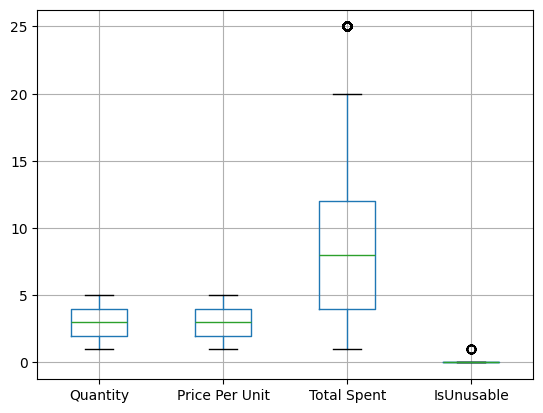

In [75]:
df.boxplot()

In [ ]:
df['IsUnusable'].value_counts(dropna=False)     #Only 26 True values so shown as outlier

IsUnusable
False    9974
True       26
Name: count, dtype: int64

In [77]:
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Total Spent'] < Q1 - 1.5*IQR) | (df['Total Spent'] > Q3 + 1.5*IQR)]
outliers

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,IsUnusable
10,TXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-11-07,False
51,TXN_6342161,Salad,5,5.0,25.0,Unavailable,Takeaway,2023-01-08,False
52,TXN_8914892,Salad,5,5.0,25.0,Digital Wallet,Unavailable,2023-03-15,False
96,TXN_5220895,Salad,5,5.0,25.0,Cash,In-Store,2023-06-10,False
100,TXN_9517146,Salad,5,5.0,25.0,Cash,Takeaway,2023-10-30,False
...,...,...,...,...,...,...,...,...,...
9791,TXN_1232346,Salad,5,5.0,25.0,Digital Wallet,In-Store,2023-01-04,False
9805,TXN_9506076,Salad,5,5.0,25.0,Unavailable,Unavailable,2023-01-17,False
9879,TXN_6393305,Salad,5,5.0,25.0,Digital Wallet,In-Store,2023-10-19,False
9908,TXN_8922585,Salad,5,5.0,25.0,Credit Card,Unavailable,2023-06-22,False


- Doesn't seem to be any unreal transactions

In [78]:
clean_df = df[~df['IsUnusable']].copy()

In [79]:
assert np.isclose(clean_df['Total Spent'], clean_df['Quantity']*clean_df['Price Per Unit'], rtol=0.01).all()

In [80]:
clean_df.isna().sum()
clean_df.describe()
clean_df.shape

(9974, 9)

In [81]:
org_shape, df.shape
org_desc
df.describe()
org_nulls, df.isna().sum()

(Transaction ID         0
 Item                 333
 Quantity             479
 Price Per Unit       533
 Total Spent          502
 Payment Method      2579
 Location            3265
 Transaction Date     159
 dtype: int64,
 Transaction ID        0
 Item                  2
 Quantity             23
 Price Per Unit        6
 Total Spent          23
 Payment Method        9
 Location              8
 Transaction Date    460
 IsUnusable            0
 dtype: int64)

In [82]:
log

['Changed data type of Quantity to Int64 and Price Per Unit, Total Spent float64',
 'Changed Transaction Date datatype to datetime',
 'Stripped and titled str columns',
 'Looked up Price Per Unit values (where NaN) compare with Item to fill',
 'Set the missing Item to Item with the same Price Per Unit, and where multiple Items had same price filled the missing item with most selling',
 'Created IsUnusable flag column to highlight columns missing 2 numeric columns -instead of dropping',
 'Set the missing Price Per Unit to Total Spent / Quantity',
 'After assigning Price Per Unit missing values popped up in Item again, dealt the same way as earlier',
 'Set Quantity = Total Spent / Price Per Unit where missing',
 'Set Total Spent = Quantity * Price Per Unit where missing',
 'marked missing Location and Payment Method as Unavailable']

- All rows kept 
- More records with Quantity, Price Per Unit, and Total Spent because of the lookups
- No unexpected deviations
- Nulls reduced from 100-1000s to 10s. Transaction date NULLs increased because of removal of the invalid entries assigned as NULL

In [ ]:
# df.to_csv('Clean Cafe_sales.csv', index=False)
# clean_df.to_csv('Clean Cafe_sales_without_unusable.csv',index=False)